In [1]:
library(data.table)
library(stringr)
library(UpSetR)
library(data.table)
library(ggplot2)
library(ggrepel)

Warning message:
“程辑包‘ggplot2’是用R版本4.1.3 来建造的”


# eQTL_summary

In [2]:
cts = c('CD14Mono', 'CD16Mono', 'cDC', 'pDC','CD4T','CD8T', 'NK','T_Prolif', 'B', 'Plasma')

In [3]:
eQTL_n = c()
eGene_n =  c()
egene_l = list()
for (ct in cts) {
    df = data.frame(fread(paste0("./res/combine-All/",ct,"_cis_fdr005.csv")))
    eQTL_n = append(eQTL_n,dim(df[df$FDR < 0.05,])[1])
    eGene_n = append(eGene_n,length(unique(df[df$FDR < 0.05,]$gene)))
    cd = paste0(ct)
    print(cd)
    print(length(unique(df[df$FDR < 0.05,]$gene)))
    egene_l[[cd]]= unique(df[df$FDR < 0.05,]$gene)
    }

[1] "CD14Mono"
[1] 5753
[1] "CD16Mono"
[1] 3497
[1] "cDC"
[1] 4050
[1] "pDC"
[1] 2168
[1] "CD4T"
[1] 7674
[1] "CD8T"
[1] 7393
[1] "NK"
[1] 5357
[1] "T_Prolif"
[1] 1349
[1] "B"
[1] 5890
[1] "Plasma"
[1] 1609


In [4]:
eqtl_summary = data.frame(ct = cts,eQTL = eQTL_n ,eGene =eGene_n )

In [5]:
eqtl_summary$ct = factor(eqtl_summary$ct,levels = eqtl_summary$ct)

In [6]:
cc = c('#FFDAB9','#CD6600', '#8B4500', '#FF8C00','#3D83C5','#A2D8E5','#917FBA','#696969','#F1A1C2','#E7211A')

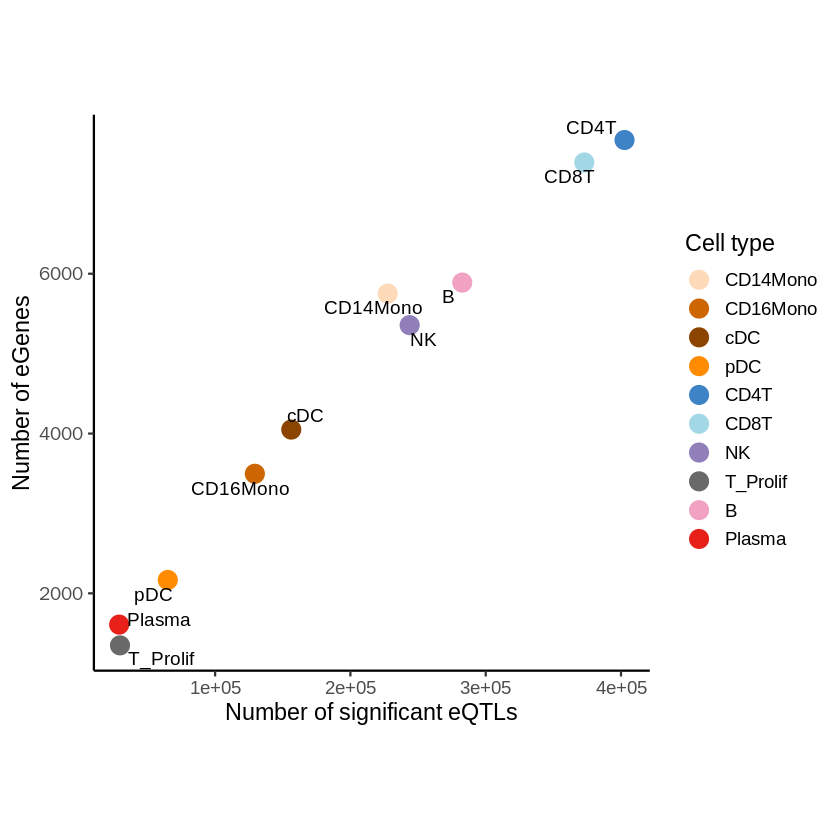

In [7]:
p <- ggplot(eqtl_summary,
       aes(x = eQTL,
           y = eGene,
           color = ct,
           label = ct)) +
  geom_point(size = 5) +
  geom_text_repel(
    size = 4,
    color = "black",
    show.legend = FALSE
  ) +
  scale_color_manual(values = cc) +
  theme_classic(base_size = 14) +
  labs(
    x = "Number of significant eQTLs",
    y = "Number of eGenes",
    color = "Cell type"
  )+theme(aspect.ratio = 1)
p

In [8]:
edf = data.frame()
egene_l = c()
cts = c('CD14Mono', 'CD16Mono', 'cDC', 'pDC','CD4T','CD8T', 'NK','T_Prolif', 'B', 'Plasma')
for (ct in cts){
    df = data.frame(fread(paste0("./res/combine-All/",ct,"_cis_fdr005.csv")))
    df = df[df$FDR < 0.05,]
    egene_l[[ct]] = unique(df[df$FDR < 0.05,]$gene)
    }

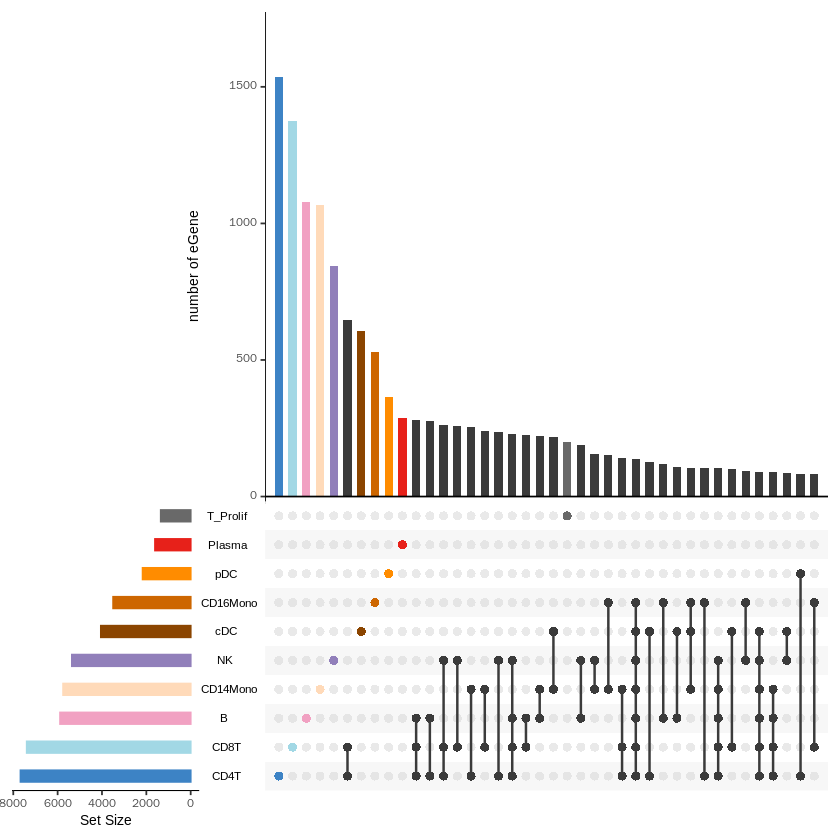

In [9]:
upset(fromList(egene_l),mainbar.y.label = 'number of eGene',show.numbers = FALSE,
      sets = c('CD14Mono', 'CD16Mono', 'cDC', 'pDC','CD4T',
               'CD8T', 'NK','T_Prolif', 'B', 'Plasma'),mb.ratio = c(0.6, 0.4),
      order.by = "freq",
     sets.bar.color = c(cc[5],cc[6],cc[9],cc[1],cc[7],cc[3],cc[2],cc[4],cc[10],cc[8]),
     queries = list(#list(query = intersects, params = list(ct2[11]),color = cc[11], active = T),
         list(query = intersects, params = list(cts[1]),color = cc[1], active = T),
                   list(query = intersects, params = list(cts[2]),color = cc[2], active = T),
                   list(query = intersects, params = list(cts[3]),color = cc[3], active = T),
                   list(query = intersects, params = list(cts[4]),color = cc[4], active = T),
                   list(query = intersects, params = list(cts[5]),color = cc[5], active = T),
                   list(query = intersects, params = list(cts[6]),color = cc[6], active = T),
                   list(query = intersects, params = list(cts[7]),color = cc[7], active = T),
                   list(query = intersects, params = list(cts[8]),color = cc[8], active = T),
                   list(query = intersects, params = list(cts[9]),color = cc[9], active = T),
                   list(query = intersects, params = list(cts[10]),color = cc[10], active = T)
                   #list(query = intersects, params = list(ct2[1]),color = cc[1], active = T)
                   ))

In [10]:
edf = data.frame()
egene_l = c()
cts = c('CD14Mono', 'CD16Mono', 'cDC', 'pDC','CD4T','CD8T', 'NK','T_Prolif', 'B', 'Plasma')
for (ct in cts){
    df = data.frame(fread(paste0("./res/combine-All/",ct,"_cis_fdr005.csv")))
    temp1 = df[df$FDR < 0.05,]
    temp  = data.frame('gene' = unique(temp1$gene),'ct' = ct)
    edf = rbind(edf,temp)
    }

In [11]:
e = data.frame(table(data.frame(table(edf$gene))$Freq))
e$Var1 = as.character(e$Var1)
e$Var1 =as.numeric(e$Var1)
e = e[order(e$Var1),]

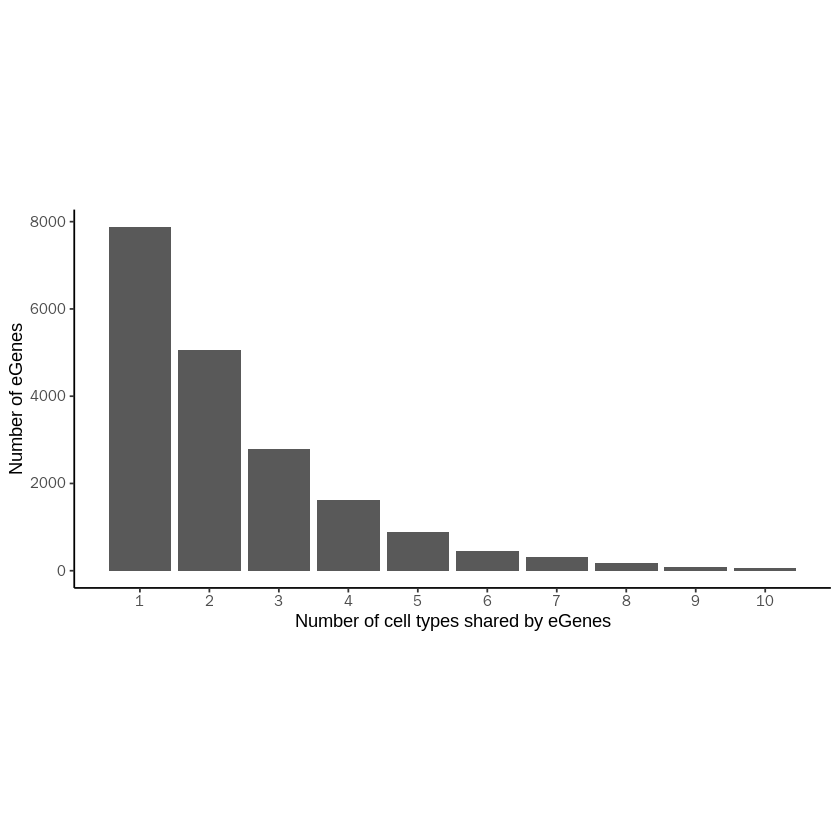

In [12]:
library(ggplot2)
p1 <- ggplot(e, aes(x = Var1, y = Freq)) +
  geom_bar(stat = "identity") +
  labs( x = "Number of cell types shared by eGenes", y = "Number of eGenes")+theme_classic()+scale_x_continuous(breaks = c(seq(1,10)))+
theme(panel.grid.major = element_blank(),aspect.ratio = 0.5,
    panel.grid.minor = element_blank())#+ylim(0,4000)
p1

# Interaction eQTL

In [13]:
inte_all = data.frame()
for (ct in cts) {
    res = read.csv(paste0('./res/combine-All/',ct,'_cis_fdr005.csv'))
    res$eqtl = paste0(res$snps,'-',res$gene)
    inte = data.frame(fread(paste0('./res/T1D_interaction/',ct,'_cis_interaction.csv')))
    inte$eqtl = paste0(inte$snps,'-',inte$gene)
    inte = inte[inte$eqtl %in% res$eqtl,]
    inte$FDR = p.adjust(inte$pvalue,method = 'BH')
    inte = inte[inte$FDR < 0.05,]
    inte$ct = ct
    inte_all = rbind(inte_all,inte)
    }

In [14]:
write.csv(inte_all,'./res/T1D_inte_eQTL.csv')

In [15]:
inte_all$gene_ct = paste0(inte_all$gene,'-',inte_all$ct)
inte_all2 = inte_all[!duplicated(inte_all$gene_ct),]

In [16]:
inter_count = data.frame(table(inte_all2$ct))

In [17]:
cts = c('CD14Mono', 'CD16Mono', 'cDC', 'pDC','CD4T','CD8T', 'NK','T_Prolif', 'B', 'Plasma')
cc = c('#FFDAB9','#CD6600', '#8B4500', '#FF8C00','#3D83C5','#A2D8E5','#917FBA','#696969','#F1A1C2','#E7211A')
names(cc) = cts


载入程辑包：‘dplyr’


The following objects are masked from ‘package:data.table’:

    between, first, last


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




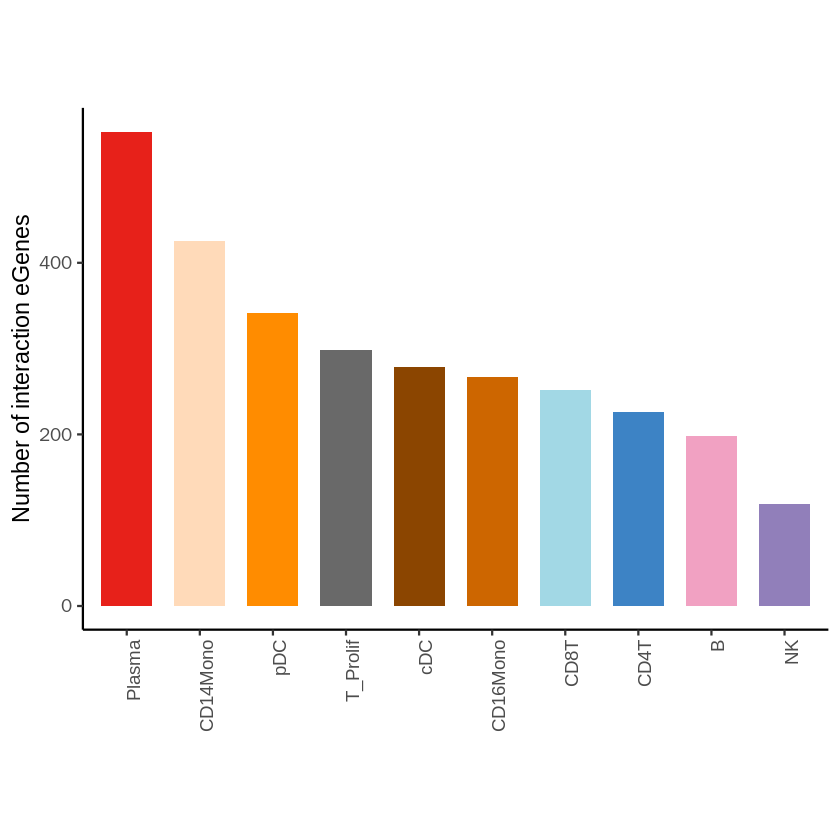

In [18]:
library(ggplot2)
library(dplyr)

plot_df <- inter_count %>%
  arrange(Freq) %>%
  mutate(
    Var1 = factor(Var1, levels = rev(Var1))
  )

p <- ggplot(
  plot_df,
  aes(
    x = Var1,
    y = Freq,
      fill = Var1
  )
) +
  geom_col(
    width = 0.7,
    #fill = Var1
  ) +
  theme_classic(base_size = 14) +
  labs(
    x = NULL,
    y = "Number of interaction eGenes"
  ) +
  theme(aspect.ratio = 0.7,
    axis.text.x = element_text(
      angle = 90,
      hjust = 1
    ),
    legend.position = "none"
  ) +scale_fill_manual(values = cc)
p 

In [19]:
#GO enrichment results from metascape
go <- read.csv('./res/GO_sum.csv',row.names = 1)

In [20]:
rownames(go) <- go$Description
go = go[cts]
go = -go

In [21]:
library(pheatmap)
library(grid)
library(RColorBrewer)
bk = c(0,-log10(0.05),3,6,9,12)
col = brewer.pal(9,'Oranges')[c(5,7,8,9)]

Warning message:
“程辑包‘RColorBrewer’是用R版本4.1.3 来建造的”


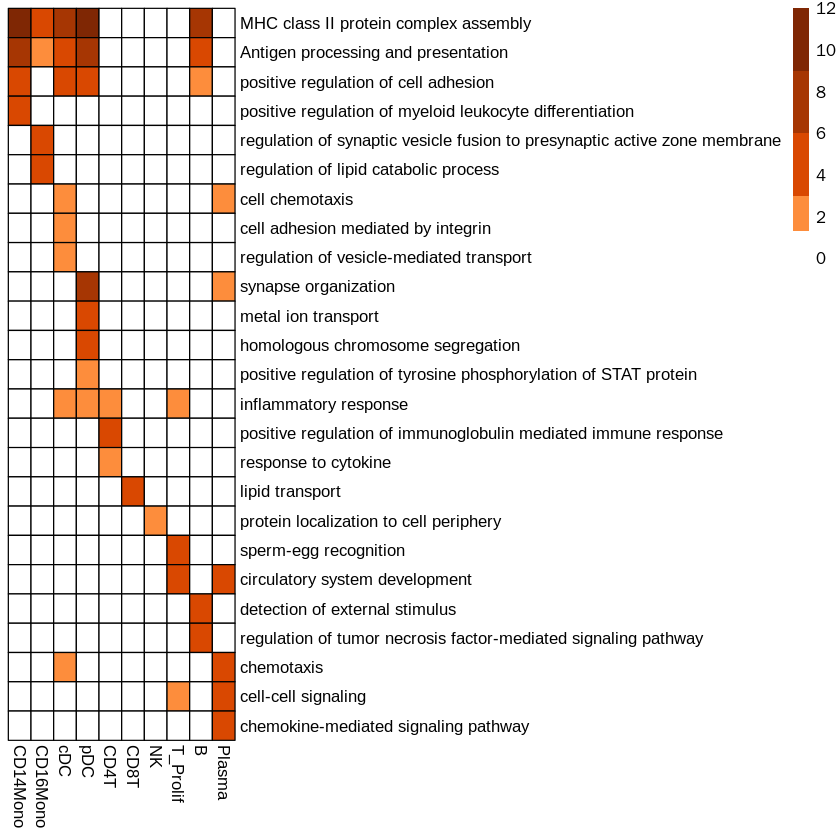

In [22]:
heatmap <- pheatmap(go,cluster_rows = FALSE,cluster_cols = FALSE,
                    breaks = bk,color = c('white',col),border_color = 'black')

In [23]:
ee = c('HLA-DRB1','HLA-DQA1','HLA-DQB1','HLA-DQB2',
       'IL12B','TNFSF11','IL5','GATA2',
       'CPLX2','CPLX1','SLC6A20',
       'CXCL9','RAC1','CCL2','CXCR6',
       'CCR3','FLT1','CCL22','ACKR2',
       'IFNG','IL17RD','XCL1','XCL2',
       'TNF','IL1A','APOC2','INHBA'
 )

In [24]:
inte_all = read.csv('./res/T1D_inte_eQTL.csv',row.names = 1)

In [25]:
inte_all = inte_all[order(inte_all$pvalue),]
inte_all$gene_ct = paste0(inte_all$gene,'-',inte_all$ct)

In [26]:
inte_all2 = inte_all[!duplicated(inte_all$gene_ct),]

In [27]:
inte_all3 = inte_all2[inte_all2$gene %in% ee,]

In [28]:
library(dplyr)
library(tidyr)
library(pheatmap)

In [29]:
inte_all3 = inte_all3[c('gene','ct','FDR')]
df <- inte_all3 %>%
  dplyr::select(gene, ct, FDR) %>%
  mutate(score = -log10(FDR))
heat_df <- df %>%
  select(gene, ct, score) %>%
  pivot_wider(
    names_from = ct,
      
    values_from = score
  )

In [30]:
mat <- as.data.frame(heat_df)
rownames(mat) <- mat$gene
mat$gene <- NULL
mat <- as.matrix(mat)
mat[is.na(mat)] <- 0

In [31]:
mat <- mat[, cts[cts %in% colnames(mat)], drop = FALSE]

In [32]:
library(pheatmap)
library(grid)
library(RColorBrewer)
bk = c(0,-log10(0.05),3,6,9,12)
col = brewer.pal(9,'Reds')[c(5,7,8,9)]

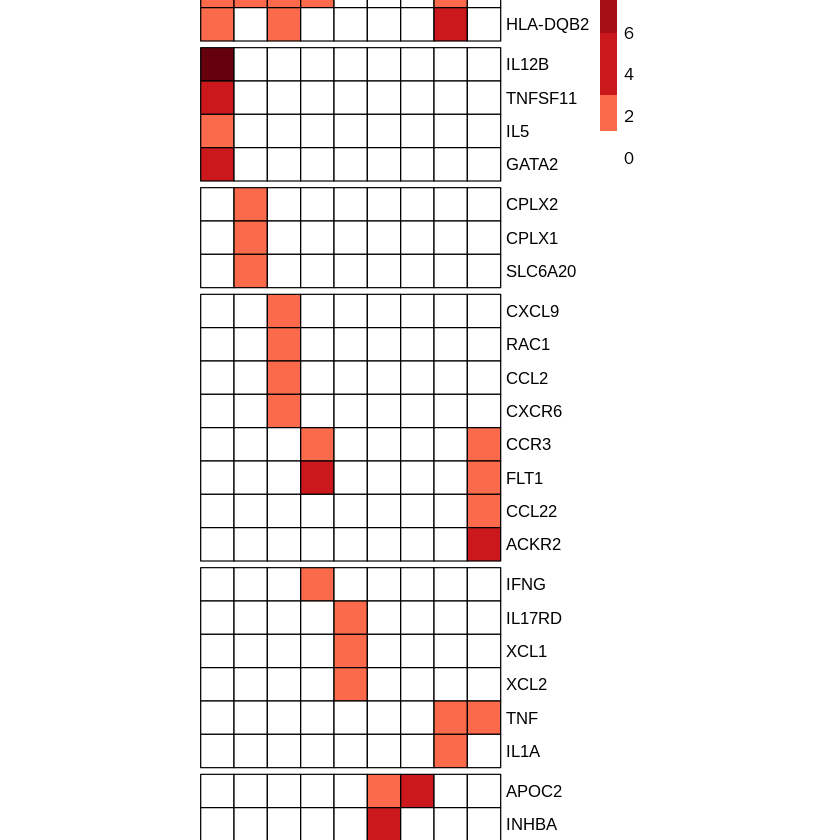

In [33]:
heatmap <- pheatmap(mat[ee,],cluster_rows = FALSE,cluster_cols = FALSE,
                    gaps_row = c(4,8, 11,19,25),  cellwidth = 20,cellheight = 20,
                    breaks = bk,clustering_method = 'ward.D2',
         color = c('white',col),border_color = 'black')

In [34]:
geno = data.frame(fread('./input/disease_all_geno/SNP.txt'))
rownames(geno) <- geno$V1
geno = geno[2:ncol(geno)]

Warning message in fread("./input/disease_all_geno/SNP.txt"):
“检测到 163 个列名，然而数据共有 164 列（文件不合法）。添加了 1 个额外列名作为第一列，并被用于猜测行名或索引。若上述猜测不正确，可在后续使用setnames()进行修改，或修复用于生成该文件的文件写入命令以生成有效的文件。”


In [35]:
cli =  read.table('./input/disease_all_geno/Covariates.txt',header = TRUE)

In [36]:
eg = 'HLA-DRB1'
es = '6:SNP_DQB1_32737124:A:G'
ed_all = data.frame()
for (ct in c('B')){
    exp = read.table(paste0('./input/disease_all_geno/',ct,'_GE.txt'))
    re = intersect(colnames(geno),colnames(exp))
    ed = data.frame(t(rbind(exp[eg,re],rbind(geno[es,re],cli['Disease',re]))))
    colnames(ed) = c('gene','geno','Disease')
    ed$geno = as.character(ed$geno)
    ed$ct = ct
    ed_all = rbind(ed_all,ed)
    }

In [37]:
ed_all[ed_all$Disease == 0,'Disease'] = 'HC'
ed_all[ed_all$Disease == 1,'Disease'] = 'T1D'
expr_df = ed_all

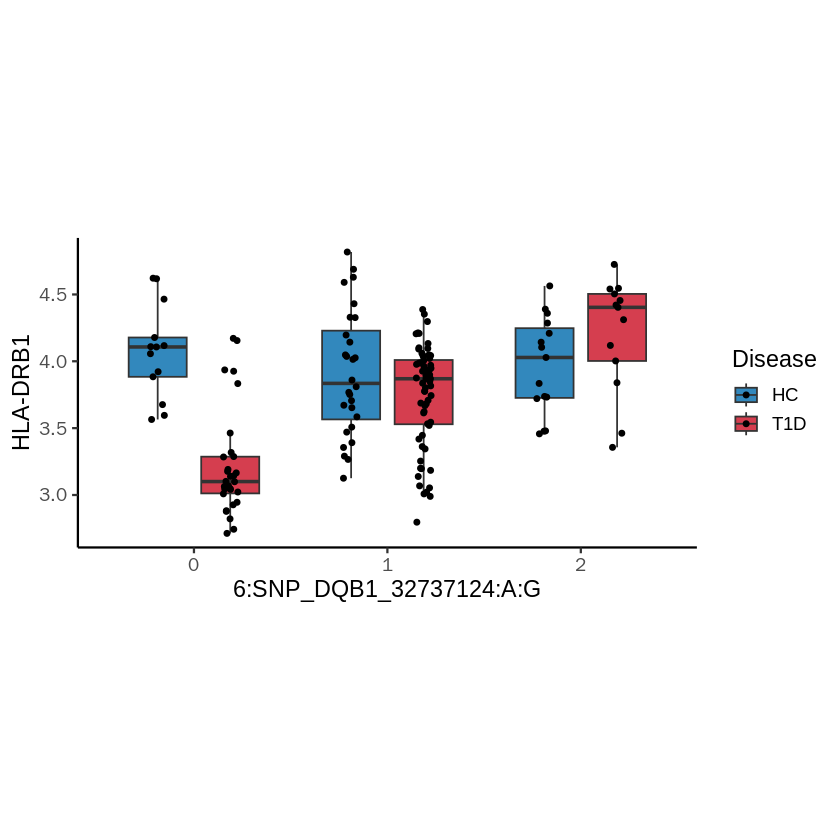

In [38]:
p <- ggplot(
  expr_df,
  aes(
    x = factor(geno),
    y = gene,
    fill = Disease,
    #color = Disease
  )
) +

# grouped boxplot
geom_boxplot(
  position = position_dodge(width = 0.75),
  width = 0.6,
  #alpha = 0.8,
  outlier.shape = NA
) +

# individual donors
geom_jitter(
  aes(group = Disease),
  position = position_jitterdodge(
    jitter.width = 0.08,
    dodge.width = 0.75
  ),
  #alpha = 0.8,
  size = 1.3
) +

scale_color_manual(
  values = c(
    "HC" = "#3288BD",
    "T1D" = "#D53E4F"
  )
) +

scale_fill_manual(
  values = c(
    "HC" = "#3288BD",
    "T1D" = "#D53E4F"
  )
) +

theme_classic(base_size = 14) +

labs(
  x = es,
  y = eg,
  color = "Disease",
  fill = "Disease"
)+theme(aspect.ratio = 0.5)
p

In [39]:
eg = 'CCR3'
es = '3:45876046:T:A'
ed_all = data.frame()
for (ct in c('pDC')){
    exp = read.table(paste0('./input/disease_all_geno/',ct,'_GE.txt'))
    re = intersect(colnames(geno),colnames(exp))
    ed = data.frame(t(rbind(exp[eg,re],rbind(geno[es,re],cli['Disease',re]))))
    colnames(ed) = c('gene','geno','Disease')
    ed$geno = as.character(ed$geno)
    ed$ct = ct
    ed_all = rbind(ed_all,ed)
    }

In [40]:
ed_all[ed_all$Disease == 0,'Disease'] = 'HC'
ed_all[ed_all$Disease == 1,'Disease'] = 'T1D'
expr_df = ed_all

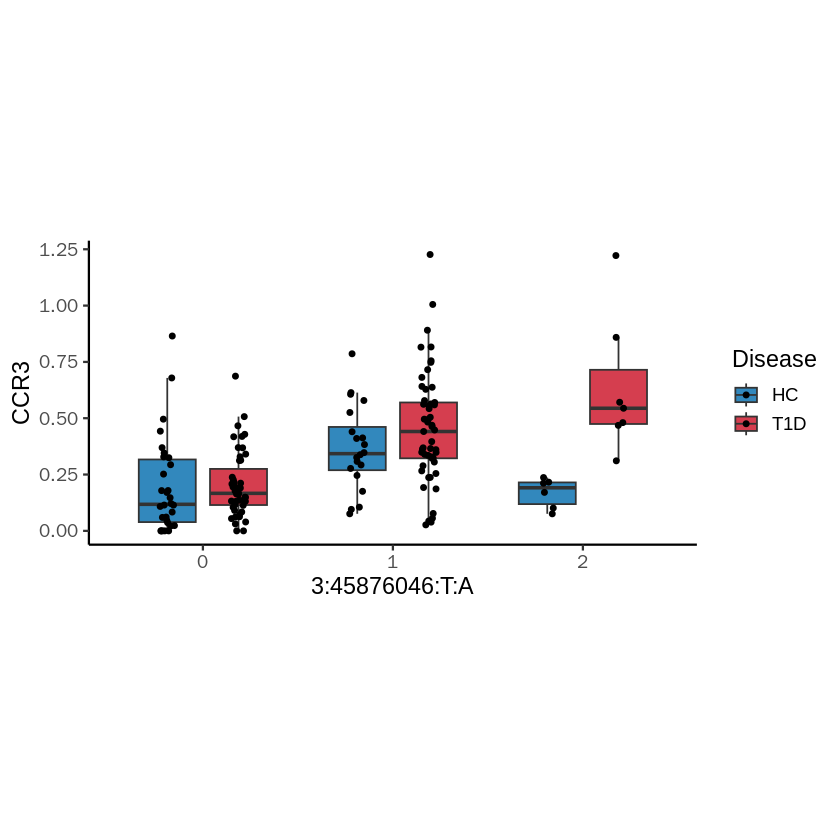

In [41]:
p <- ggplot(
  expr_df,
  aes(
    x = factor(geno),
    y = gene,
    fill = Disease,
    #color = Disease
  )
) +

# grouped boxplot
geom_boxplot(
  position = position_dodge(width = 0.75),
  width = 0.6,
  #alpha = 0.8,
  outlier.shape = NA
) +

# individual donors
geom_jitter(
  aes(group = Disease),
  position = position_jitterdodge(
    jitter.width = 0.08,
    dodge.width = 0.75
  ),
  #alpha = 0.8,
  size = 1.3
) +

scale_color_manual(
  values = c(
    "HC" = "#3288BD",
    "T1D" = "#D53E4F"
  )
) +

scale_fill_manual(
  values = c(
    "HC" = "#3288BD",
    "T1D" = "#D53E4F"
  )
) +

theme_classic(base_size = 14) +

labs(
  x = es,
  y = eg,
  color = "Disease",
  fill = "Disease"
)+theme(aspect.ratio = 0.5)
p